In [11]:
import pandas as pd 

users_df = pd.read_csv("../data3/users_clean.csv") 
books_df = pd.read_csv("../data3/books_clean.csv")
orders_df = pd.read_csv("../data3/orders_clean.csv")

In [3]:
daily_revenue = orders_df.groupby('date')['paid_price'].sum().reset_index()
daily_revenue.columns = ['date', 'revenue']
daily_revenue['date'] = pd.to_datetime(daily_revenue['date'])
top5 = daily_revenue.nlargest(5, 'revenue')
print("Top 5 days by revenue:")
print(top5.to_string(index=False))

Top 5 days by revenue:
      date  revenue
2024-11-16  3278.10
2025-01-31  2788.84
2024-11-12  2785.95
2024-07-25  2774.58
2024-12-23  2667.06


In [4]:
parent = {i: i for i in users_df.index}

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(x, y):
    parent[find(x)] = find(y)

def is_same_user(r1, r2):
    matches = (
        (r1['name'] == r2['name']) +
        (r1['address'] == r2['address']) +
        (r1['phone'] == r2['phone']) +
        (r1['email'] == r2['email'])
    )
    return matches >= 3

records = users_df.reset_index().to_dict('records')

for i in range(len(records)):
    for j in range(i + 1, len(records)):
        if is_same_user(records[i], records[j]):
            union(records[i]['index'], records[j]['index'])

unique_users = len(set(find(i) for i in users_df.index))
print(f"Real unique users: {unique_users}")

Real unique users: 3290


In [5]:
print("Number of unique sets of authors: "+str(books_df['author'].nunique()))

Number of unique sets of authors: 325


In [6]:
merged = orders_df.merge(books_df, left_on='book_id', right_on='id')
author_sales = merged.groupby('author')['quantity'].sum().reset_index()
author_sales.columns = ['author', 'total_sold']
most_popular = author_sales.nlargest(1, 'total_sold')
print("The name of most popular author and number of book sold:")
print(most_popular.to_string(index=False))

The name of most popular author and number of book sold:
        author  total_sold
Benjamin Mills         156


In [7]:
users_df['user_group'] = [find(i) for i in users_df.index]

merged = orders_df.merge(users_df[['id', 'user_group']], left_on='user_id', right_on='id')

spending = merged.groupby('user_group')['paid_price'].sum().reset_index()
spending.columns = ['user_group', 'total_spent']

top_group = spending.nlargest(1, 'total_spent')['user_group'].values[0]
print(f"Top spending group: {top_group}, Total: {spending[spending['user_group'] == top_group]['total_spent'].values[0]}")

all_ids = users_df[users_df['user_group'] == top_group]
print(all_ids[['id', 'name', 'email', 'phone', 'address']])

Top spending group: 3063, Total: 1207.48
         id              name                  email       phone  \
527   49715       Tony Sawayn  robby@padberg.example  5267081955   
3063  50963  Long Bogisich IV  robby@padberg.example  5267081955   

                                             address  
527   Apt. 755 91534 Edgar Dale, Gradyland, AL 98124  
3063  Apt. 755 91534 Edgar Dale, Gradyland, AL 98124  


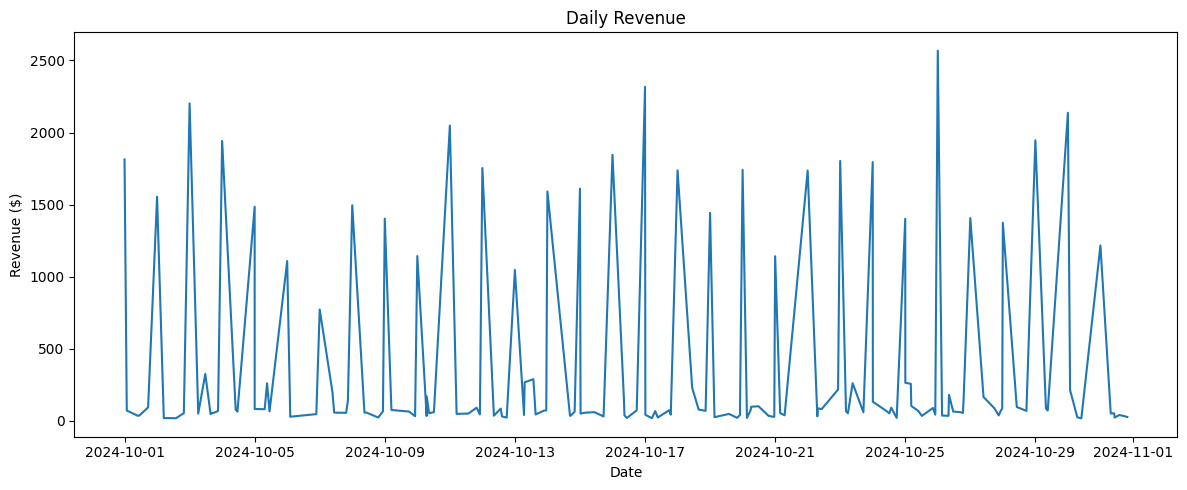

In [10]:
import matplotlib.pyplot as plt

month = daily_revenue[
    (daily_revenue['date'].dt.month == 1) & 
    (daily_revenue['date'].dt.year == 2024)
]

plt.figure(figsize=(12, 5))
plt.plot(month['date'], month['revenue'])
plt.title('Daily Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()